## 1. Criterios de éxito Sprint 1 vs Métricas Sprint 4

Los criterios de éxito definidos en el Sprint 1 coinciden con las métricas priorizadas en el Sprint 4, ya que ambos enfoques buscan evaluar si el modelo genera valor real para el negocio hotelero.

En el Sprint 1, el éxito del proyecto se definió en función de tres objetivos principales: detectar cancelaciones, reducir pérdidas económicas y activar acciones operativas. En el Sprint 4, estos objetivos se traducen en métricas concretas del modelo: **recall**, **F1-score** y **AUC-ROC**.

| Sprint 1: Criterio de éxito | Sprint 4: Métrica asociada | Coincidencia |
|---|---|---|
| Alcanzar un recall ≥ 80% | Recall | Permite detectar la mayor cantidad posible de reservas que realmente se cancelarán |
| Reducir pérdidas asociadas a cancelaciones y no-show | Recall | Reduce falsos negativos, es decir, cancelaciones reales no detectadas |
| Activar acciones preventivas sobre reservas riesgosas | Recall / F1-score | Permite intervenir reservas con alto riesgo sin generar demasiadas alertas innecesarias |
| Superar un modelo base o regla simple | Recall / F1-score / AUC-ROC | Demuestra que el modelo aporta más valor que una decisión manual o básica |
| Lograr un AUC ≥ 0.75 | AUC-ROC | Valida que el modelo discrimine correctamente entre reservas canceladas y no canceladas |

Por esta razón, los criterios de éxito del Sprint 1 y las métricas del Sprint 4 son consistentes: ambos priorizan la capacidad del modelo para anticipar cancelaciones y generar decisiones accionables para el negocio.

La priorización final de métricas queda de la siguiente manera:

| Prioridad | Métrica | Rol | Justificación |
|---:|---|---|---|
| 1 | Recall | Métrica principal | Reduce cancelaciones reales no detectadas |
| 2 | F1-score | Métrica secundaria | Balancea detección de cancelaciones y falsas alertas |
| 3 | AUC-ROC | Métrica de validación general | Evalúa la capacidad del modelo para separar reservas canceladas y no canceladas |
| 4 | Precision | Métrica de apoyo | Controla costos por intervenciones innecesarias |
| 5 | Accuracy | Métrica complementaria | Resume el acierto general, pero no diferencia el costo de cada error |

---

## 2. Matriz costo-beneficio: FP vs FN y beneficio de TP

Para evaluar el valor económico del modelo, se analiza el impacto de los principales resultados de clasificación: **True Positive (TP)**, **False Positive (FP)** y **False Negative (FN)**.

La lógica económica utilizada es la siguiente:

- Un **False Negative (FN)** es el error más costoso, porque el hotel no detecta una reserva que realmente se cancelará y pierde la oportunidad de activar una acción preventiva.
- Un **False Positive (FP)** genera un costo operativo, porque el hotel interviene una reserva que finalmente no se iba a cancelar.
- Un **True Positive (TP)** genera valor, porque permite anticipar una cancelación real y activar una acción preventiva.
- Sin embargo, un **True Positive (TP)** también genera un costo operativo, porque la acción preventiva igualmente debe ejecutarse.

Por ello, siguiendo la lógica de Business Value presentada en clase, el valor del modelo no se calcula únicamente descontando el costo de los falsos positivos. Se descuenta el costo de todas las reservas intervenidas por el modelo, es decir, tanto **TP** como **FP**.

La fórmula utilizada es:

```text
BV = Gain × TP - Cost × (TP + FP)

## 3. Impacto económico anual del modelo

Para estimar el impacto económico anual del modelo, primero se anualizó la cantidad de reservas, ya que el dataset no contiene años completos para 2015 y 2017.

La proyección anual se calculó usando la siguiente fórmula:

```text
Proyección anual = promedio mensual de reservas × 12
```

### Proyección anual de reservas

| Año | Meses disponibles | Reservas observadas | Promedio mensual | Proyección anual |
|---:|---:|---:|---:|---:|
| 2015 | 6 | 21,996 | 3,666.00 | 43,992 |
| 2016 | 12 | 56,707 | 4,725.58 | 56,707 |
| 2017 | 8 | 40,687 | 5,085.88 | 61,030 |

Esta proyección permite comparar los años de forma más justa, ya que 2015 y 2017 tienen información parcial. En lugar de comparar directamente los totales observados, se usa una estimación anual basada en el promedio mensual de reservas.

---

### Modelo seleccionado para despliegue

El modelo final seleccionado para el despliegue es el **Tuned XGBoost del Sprint 4**.

| Métrica | Sprint 3 Baseline RF | Sprint 4 Tuned XGB | Mejora |
|---|---:|---:|---:|
| Recall | 0.769 | 0.775 | +0.8 pp |
| F1-score | 0.816 | 0.813 | -0.4 pp |
| AUC-ROC | 0.935 | 0.936 | +0.1 pp |
| Accuracy | 0.867 | 0.867 | +0.0 pp |

Aunque la mejora frente al baseline no es muy grande, el modelo Tuned XGB mantiene un desempeño alto y mejora ligeramente el **recall** y el **AUC-ROC**, que son métricas relevantes para detectar cancelaciones y validar la capacidad general de separación del modelo.

El **recall** es especialmente importante porque permite identificar una mayor proporción de reservas que realmente se cancelarán. En términos de negocio, esto aumenta la oportunidad de aplicar acciones preventivas antes de que la pérdida ocurra.

---

### Supuestos económicos

| Concepto | Valor |
|---|---:|
| Tasa de cancelación estimada | 37% |
| ADR promedio | 101.83 |
| Recall del modelo final | 0.7753 |
| F1-score del modelo final | 0.8125 |
| Precision del modelo final | 0.8535 |
| <span style="color:red"><b>Costo operativo por acción preventiva</b></span> | <span style="color:red"><b>5.00</b></span> |
| Efectividad base de acciones preventivas | 25% |
| <span style="color:red"><b>Gain esperado por TP</b></span> | <span style="color:red"><b>25.46</b></span> |

La efectividad de acciones preventivas se fija en **25%** como escenario base. Esto significa que no se asume que todas las cancelaciones detectadas se recuperan, sino que una parte de las reservas identificadas a tiempo puede convertirse en revenue protegido mediante acciones como confirmaciones, depósitos, campañas de retención u overbooking controlado.

Este supuesto se considera un escenario intermedio: no es tan conservador como asumir que casi ninguna alerta genera valor, pero tampoco asume que el hotel podrá recuperar la mayoría de cancelaciones detectadas.

| Escenario | Efectividad operativa | Interpretación |
|---|---:|---|
| Conservador | 10% | Solo una pequeña parte de las alertas se convierte en revenue recuperado |
| Base | 25% | Una parte razonable de las cancelaciones detectadas logra recuperarse o compensarse |
| Optimista | 40% | El hotel ejecuta muy bien las acciones preventivas y recupera más valor |

Para este análisis se usa el escenario **base de 25%**.

---

### Fórmulas de estimación

```text
Cancelaciones estimadas = reservas proyectadas × tasa de cancelación
```

```text
Cancelaciones detectadas = cancelaciones estimadas × recall
```

```text
Revenue en riesgo sin modelo = cancelaciones estimadas × ADR promedio
```

```text
Revenue recuperado = cancelaciones detectadas × ADR promedio × efectividad
```

<span style="color:red"><b>En la versión corregida, primero se estima el total de reservas marcadas como riesgo por el modelo:</b></span>

```text
Reservas marcadas como riesgo = cancelaciones detectadas / precision
```

```text
Falsas alertas estimadas = reservas marcadas como riesgo - cancelaciones detectadas
```

<span style="color:red"><b>El cambio principal está en el costo operativo: ya no se calcula solo sobre las falsas alertas, sino sobre todas las acciones preventivas generadas por el modelo.</b></span>

```text
Costo acciones preventivas = reservas marcadas como riesgo × costo operativo por acción preventiva
```

```text
Ahorro neto = revenue recuperado - costo acciones preventivas
```

```text
Pérdida residual con modelo = revenue en riesgo sin modelo - ahorro neto
```

<span style="color:red"><b>La diferencia principal frente a la versión anterior es que el costo operativo no se descuenta solo sobre las falsas alertas. Siguiendo la lógica de Business Value presentada en clase, el costo se aplica a todas las reservas intervenidas por el modelo, es decir:</b></span>

```text
Costo acciones preventivas = Cost × (TP + FP)
```

<span style="color:red"><b>Esto ocurre porque tanto un verdadero positivo como un falso positivo requieren una acción operativa.</b></span>

---

### Impacto económico anual estimado

La siguiente tabla resume el impacto económico anual estimado bajo el escenario base de 25% de efectividad operativa. <span style="color:red"><b>A diferencia de la versión inicial, el costo operativo se descuenta sobre todas las acciones preventivas generadas por el modelo, no únicamente sobre las falsas alertas.</b></span>

---

### Comparación económica: sin modelo vs con modelo

En lugar de asumir que “sin modelo” equivale a cero, se considera que sin modelo existe una **pérdida potencial completa** asociada a las cancelaciones no anticipadas.

Con el modelo, parte de ese revenue puede recuperarse gracias a las acciones preventivas sobre las reservas detectadas como riesgosas.

La columna **pérdida potencial sin modelo** representa el revenue en riesgo si el hotel no anticipa cancelaciones. La columna **pérdida residual con modelo** representa la pérdida que todavía permanece después de aplicar el modelo y descontar el ahorro neto generado.

---

### Nota sobre la pérdida residual con modelo

La efectividad operativa del **25%** significa que no todas las cancelaciones detectadas por el modelo se convertirán en revenue recuperado. Se asume que solo una parte de las reservas identificadas como riesgosas podrá ser retenida o compensada mediante acciones preventivas.

El **75% restante** corresponde a casos detectados que no logran recuperarse por distintos motivos operativos o comerciales.

| Motivo | Explicación |
|---|---|
| Decisión definitiva del cliente | El cliente ya decidió cancelar y no cambia su decisión aunque el hotel intervenga |
| Acción preventiva insuficiente | La confirmación, descuento, depósito o campaña no logra retener la reserva |
| Limitaciones operativas | El equipo no logra contactar o gestionar todos los casos detectados por el modelo |
| Cancelaciones inevitables | Algunas cancelaciones ocurren por motivos externos, como cambios de viaje, salud o imprevistos |
| Tiempo de reacción limitado | La alerta puede llegar tarde o la acción preventiva puede ejecutarse fuera del momento adecuado |

La pérdida residual con modelo no representa simplemente el 75% de la pérdida inicial. También incluye las cancelaciones que el modelo no detecta, las cancelaciones detectadas que no logran recuperarse mediante acciones operativas <span style="color:red"><b>y el costo de ejecutar acciones preventivas sobre las reservas marcadas como riesgosas.</b></span>

---

### Lectura ejecutiva del impacto económico

Bajo los supuestos del análisis, el modelo permitiría reducir una parte del revenue en riesgo asociado a cancelaciones. Esta reducción proviene de detectar reservas con alta probabilidad de cancelación y convertir una parte de ellas en revenue recuperado o pérdida evitada, <span style="color:red"><b>descontando el costo operativo de las acciones preventivas.</b></span>

---

### Interpretación de negocio

El modelo no elimina completamente las pérdidas por cancelaciones, pero permite reducirlas al identificar anticipadamente una parte importante de las reservas que tienen riesgo de cancelarse.

Bajo un escenario base de **25% de efectividad en acciones preventivas**, el modelo podría generar ahorro neto anual positivo, dependiendo del volumen anual proyectado de reservas.

Este resultado muestra que el valor del modelo no está solo en mejorar métricas técnicas, sino en convertir predicciones en acciones operativas que reduzcan pérdidas económicas. <span style="color:red"><b>Además, al aplicar la fórmula de Business Value, el análisis reconoce que toda acción preventiva tiene un costo operativo, incluso cuando la alerta del modelo fue correcta.</b></span>

,Año,Reservas proyectadas,Cancelaciones estimadas,Revenue en riesgo sin modelo,Cancelaciones detectadas,Falsas alertas estimadas,Acciones preventivas,Revenue recuperado 25%,Costo acciones preventivas,Ahorro neto estimado
0,2015,43992,16277,1657487,12620,2166,14786,321274,73930,247344
1,2016,56707,20982,2136597,16267,2792,19059,414117,95295,318822
2,2017,61030,22581,2299423,17507,3005,20512,445684,102560,343124


,Año,Pérdida potencial sin modelo,Pérdida residual con modelo,Ahorro neto estimado
0,2015,1657487,1410143,247344
1,2016,2136597,1817775,318822
2,2017,2299423,1956299,343124


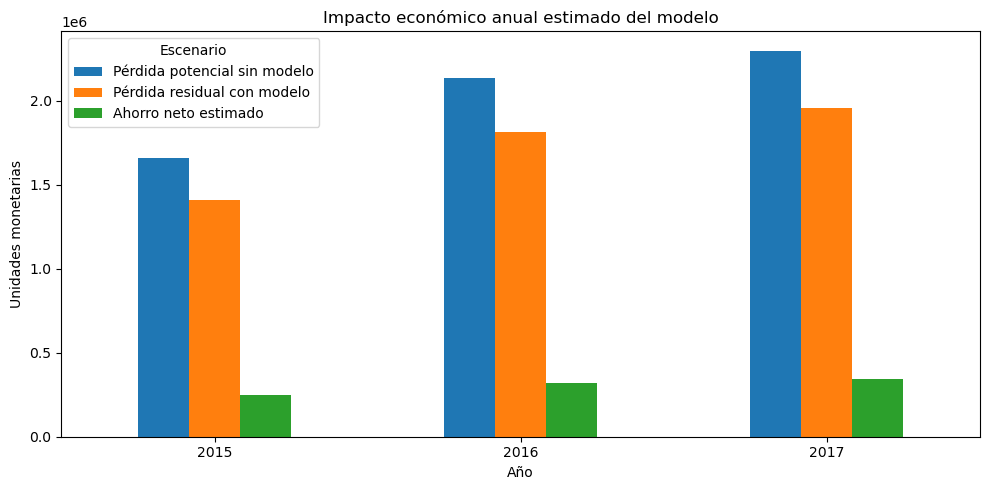

,Año,Revenue en riesgo sin modelo,Ahorro neto estimado,Reducción porcentual estimada
0,2015,"1,657,487","247,344",14.92%
1,2016,"2,136,597","318,822",14.92%
2,2017,"2,299,423","343,124",14.92%


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ========================
# Supuestos económicos
# ========================

TASA_CANCELACION = 0.37
ADR_PROMEDIO = 101.83
RECALL_MODELO = 0.7753
PRECISION_MODELO = 0.8535
EFECTIVIDAD_OPERATIVA = 0.25
COSTO_ACCION = 5.00

# ========================
# Proyección anual de reservas
# ========================

proyeccion = pd.DataFrame({
    "Año": [2015, 2016, 2017],
    "Reservas proyectadas": [43992, 56707, 61030]
})

# ========================
# Cálculos económicos corregidos
# Fórmula:
# BV = Gain * TP - Cost * (TP + FP)
# ========================

proyeccion["Cancelaciones estimadas"] = (
    proyeccion["Reservas proyectadas"] * TASA_CANCELACION
).round(0).astype(int)

proyeccion["Revenue en riesgo sin modelo"] = (
    proyeccion["Cancelaciones estimadas"] * ADR_PROMEDIO
).round(0).astype(int)

proyeccion["Cancelaciones detectadas"] = (
    proyeccion["Cancelaciones estimadas"] * RECALL_MODELO
).round(0).astype(int)

proyeccion["Acciones preventivas"] = (
    proyeccion["Cancelaciones detectadas"] / PRECISION_MODELO
).round(0).astype(int)

proyeccion["Falsas alertas estimadas"] = (
    proyeccion["Acciones preventivas"] - proyeccion["Cancelaciones detectadas"]
).astype(int)

proyeccion["Revenue recuperado 25%"] = (
    proyeccion["Cancelaciones detectadas"] * ADR_PROMEDIO * EFECTIVIDAD_OPERATIVA
).round(0).astype(int)

proyeccion["Costo acciones preventivas"] = (
    proyeccion["Acciones preventivas"] * COSTO_ACCION
).round(0).astype(int)

proyeccion["Ahorro neto estimado"] = (
    proyeccion["Revenue recuperado 25%"] - proyeccion["Costo acciones preventivas"]
).round(0).astype(int)

proyeccion["Pérdida residual con modelo"] = (
    proyeccion["Revenue en riesgo sin modelo"] - proyeccion["Ahorro neto estimado"]
).round(0).astype(int)

proyeccion["Reducción porcentual estimada"] = (
    proyeccion["Ahorro neto estimado"] / proyeccion["Revenue en riesgo sin modelo"]
)

# ========================
# Tabla de impacto anual
# ========================

impacto_anual = proyeccion[
    [
        "Año",
        "Reservas proyectadas",
        "Cancelaciones estimadas",
        "Revenue en riesgo sin modelo",
        "Cancelaciones detectadas",
        "Falsas alertas estimadas",
        "Acciones preventivas",
        "Revenue recuperado 25%",
        "Costo acciones preventivas",
        "Ahorro neto estimado"
    ]
]

display(impacto_anual)

# ========================
# Tabla comparativa: sin modelo vs con modelo
# ========================

impacto = proyeccion[
    [
        "Año",
        "Revenue en riesgo sin modelo",
        "Pérdida residual con modelo",
        "Ahorro neto estimado"
    ]
].rename(columns={
    "Revenue en riesgo sin modelo": "Pérdida potencial sin modelo"
})

display(impacto)

# ========================
# Gráfico de impacto económico anual
# ========================

ax = impacto.set_index("Año")[[
    "Pérdida potencial sin modelo",
    "Pérdida residual con modelo",
    "Ahorro neto estimado"
]].plot(kind="bar", figsize=(10, 5))

plt.title("Impacto económico anual estimado del modelo")
plt.xlabel("Año")
plt.ylabel("Unidades monetarias")
plt.xticks(rotation=0)
plt.legend(title="Escenario")
plt.tight_layout()
plt.show()

# ========================
# Lectura ejecutiva
# ========================

lectura_ejecutiva = proyeccion[
    [
        "Año",
        "Revenue en riesgo sin modelo",
        "Ahorro neto estimado",
        "Reducción porcentual estimada"
    ]
]

display(
    lectura_ejecutiva.style.format({
        "Revenue en riesgo sin modelo": "{:,.0f}",
        "Ahorro neto estimado": "{:,.0f}",
        "Reducción porcentual estimada": "{:.2%}"
    })
)

## 4. Gain curve y lift sobre baseline aleatoria

Para evaluar el valor operativo del modelo, se calcula la **gain curve** y el **lift acumulado** sobre una baseline aleatoria.

La **gain curve** muestra qué porcentaje de cancelaciones reales se logra capturar al revisar un determinado porcentaje de reservas ordenadas por riesgo. En este caso, las reservas se ordenan de mayor a menor probabilidad de cancelación estimada por el modelo final Tuned XGBoost.

El **lift acumulado** compara el desempeño del modelo contra una selección aleatoria. Un lift mayor a 1 indica que el modelo permite identificar cancelaciones mejor que revisar reservas al azar.

```text
Lift = % de cancelaciones capturadas / % de reservas revisadas

In [ ]:
=======================
# GAIN CURVE Y LIFT
# ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gain_df = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba
})

# Ordenar reservas desde mayor hasta menor probabilidad de cancelación
gain_df = gain_df.sort_values("y_proba", ascending=False).reset_index(drop=True)

# Cálculos acumulados#
gain_df["reservas_acum"] = np.arange(1, len(gain_df) + 1)
gain_df["cancelaciones_acum"] = gain_df["y_true"].cumsum()

total_reservas = len(gain_df)
total_cancelaciones = gain_df["y_true"].sum()

gain_df["pct_reservas_revisadas"] = gain_df["reservas_acum"] / total_reservas
gain_df["pct_cancelaciones_capturadas"] = gain_df["cancelaciones_acum"] / total_cancelaciones
gain_df["baseline_aleatoria"] = gain_df["pct_reservas_revisadas"]

# Lift acumulado
gain_df["lift"] = (
    gain_df["pct_cancelaciones_capturadas"] /
    gain_df["pct_reservas_revisadas"]
)

# Resumen por percentiles
percentiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

gain_summary = []

for p in percentiles:
    idx = int(np.ceil(p * total_reservas)) - 1
    row = gain_df.iloc[idx]

    gain_summary.append({
        "% reservas revisadas": f"{p:.0%}",
        "Reservas revisadas": int(row["reservas_acum"]),
        "Cancelaciones capturadas": int(row["cancelaciones_acum"]),
        "% cancelaciones capturadas": round(row["pct_cancelaciones_capturadas"] * 100, 2),
        "Baseline aleatoria (%)": round(p * 100, 2),
        "Lift": round(row["lift"], 2)
    })

gain_summary = pd.DataFrame(gain_summary)

display(gain_summary)

,% reservas revisadas,Reservas revisadas,Cancelaciones capturadas,% cancelaciones capturadas,Baseline aleatoria (%),Lift
0,5%,1193,1193,13.50,5.0,2.70
1,10%,2385,2385,26.98,10.0,2.70
2,20%,4769,4659,52.71,20.0,2.64
3,30%,7153,6381,72.19,30.0,2.41
4,40%,9537,7514,85.01,40.0,2.13
5,50%,11921,8148,92.18,50.0,1.84


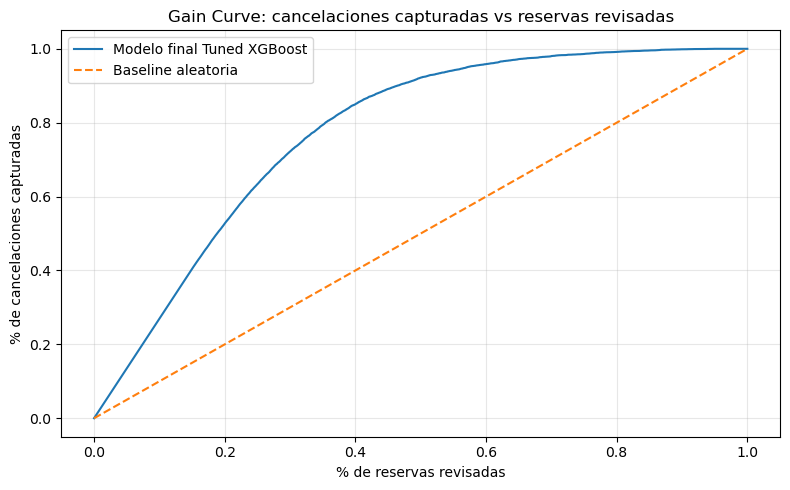

In [24]:
# ========================
# GRÁFICO GAIN CURVE
# ========================

plt.figure(figsize=(8, 5))

plt.plot(
    gain_df["pct_reservas_revisadas"],
    gain_df["pct_cancelaciones_capturadas"],
    label="Modelo final Tuned XGBoost"
)

plt.plot(
    gain_df["pct_reservas_revisadas"],
    gain_df["baseline_aleatoria"],
    linestyle="--",
    label="Baseline aleatoria"
)

plt.title("Gain Curve: cancelaciones capturadas vs reservas revisadas")
plt.xlabel("% de reservas revisadas")
plt.ylabel("% de cancelaciones capturadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

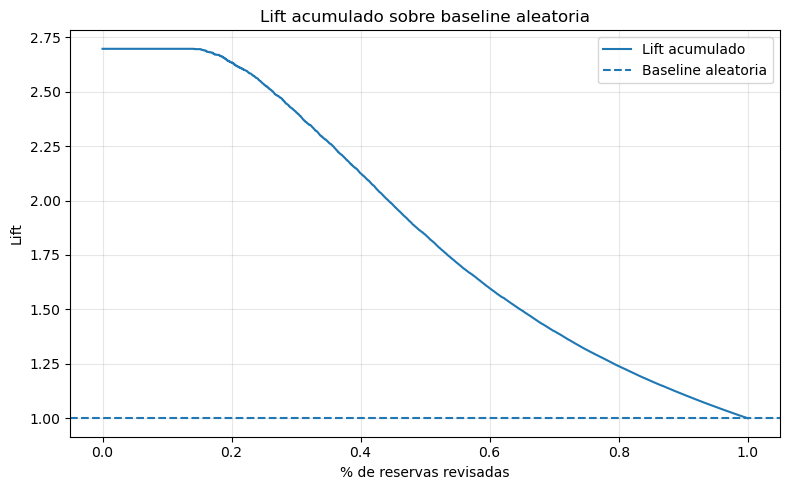

In [25]:
# ========================
# GRÁFICO LIFT ACUMULADO
# ========================

plt.figure(figsize=(8, 5))

plt.plot(
    gain_df["pct_reservas_revisadas"],
    gain_df["lift"],
    label="Lift acumulado"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Baseline aleatoria"
)

plt.title("Lift acumulado sobre baseline aleatoria")
plt.xlabel("% de reservas revisadas")
plt.ylabel("Lift")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de resultados

Los gráficos muestran que el modelo final tiene una capacidad clara para concentrar cancelaciones reales en los primeros segmentos de mayor riesgo.

En la **gain curve**, la curva del modelo se mantiene por encima de la baseline aleatoria. Esto significa que, al ordenar las reservas por probabilidad de cancelación, el modelo captura una mayor proporción de cancelaciones que una selección al azar.

En el gráfico de **lift acumulado**, el modelo presenta un lift alto en los primeros porcentajes de reservas revisadas y luego disminuye progresivamente hasta acercarse a 1 cuando se revisa el 100% de la base. Este comportamiento es esperado: el mayor valor del modelo está en los primeros segmentos, donde concentra las reservas con mayor riesgo.

Desde una perspectiva operativa, esto confirma que el hotel no necesita intervenir todas las reservas. Puede enfocar sus recursos en los grupos con mayor probabilidad de cancelación, aumentando la eficiencia de las acciones preventivas y reduciendo costos por intervenciones innecesarias.

En conclusión, la gain curve y el lift refuerzan el valor del modelo como herramienta de priorización: permite identificar antes las reservas con mayor riesgo y actuar sobre ellas de manera más eficiente que una estrategia aleatoria.

## 5. Umbral óptimo de decisión basado en valor esperado de negocio

El modelo final genera una probabilidad de cancelación para cada reserva. Para convertir esa probabilidad en una decisión operativa, se debe definir un **umbral de decisión**.

Por defecto, muchos modelos usan un umbral de **0.50**:

```text
Si probabilidad de cancelación ≥ 0.50 → predecir cancelación
Si probabilidad de cancelación < 0.50 → predecir no cancelación
```

Sin embargo, el umbral de **0.50** no necesariamente maximiza el valor de negocio. Ese umbral puede funcionar como referencia técnica, pero no siempre es el más adecuado cuando los costos y beneficios de una decisión son diferentes.

En este proyecto, el costo de un **falso negativo (FN)** es relevante porque representa una cancelación real no detectada, mientras que una alerta del modelo genera una acción operativa que tiene costo tanto si la alerta fue correcta como si fue innecesaria.

| Resultado | Caso | Impacto económico |
|---|---|---|
| True Positive (TP) | El modelo detecta una cancelación real | Revenue recuperado esperado, descontando el costo de la acción preventiva |
| False Positive (FP) | El modelo alerta una reserva que no iba a cancelar | Costo operativo innecesario por acción preventiva |
| False Negative (FN) | El modelo no detecta una cancelación real | Pérdida no evitada o revenue no gestionado |
| True Negative (TN) | El modelo no alerta una reserva que no iba a cancelar | Sin costo adicional |

Dado que no detectar una cancelación real puede representar una pérdida asociada al ADR, puede ser conveniente usar un umbral menor a 0.50. Esto permite detectar más cancelaciones reales, aunque aumenten algunas falsas alertas y, por lo tanto, el número de acciones preventivas.

Para traducir esta lógica a valor económico, se utilizan los siguientes supuestos:

| Concepto | Valor |
|---|---:|
| ADR promedio | 101.83 |
| Efectividad operativa base | 25% |
| Gain esperado por TP | 25.46 |
| Costo operativo por acción preventiva | 5.00 |

El **Gain esperado por TP** representa el beneficio económico esperado por detectar correctamente una cancelación real y ejecutar una acción preventiva efectiva.

```text
Gain esperado por TP = ADR promedio × efectividad operativa
```

```text
Gain esperado por TP = 101.83 × 25% = 25.46
```

Por lo tanto, siguiendo la fórmula de Business Value presentada en clase, el valor esperado de negocio para cada umbral se calcula como:

```text
BV = Gain × TP - Cost × (TP + FP)
```

Donde:

- **TP** representa las cancelaciones correctamente detectadas.
- **FP** representa las reservas alertadas como riesgosas que finalmente no se cancelaron.
- **Gain** representa el beneficio esperado por cada cancelación correctamente detectada.
- **Cost** representa el costo operativo de ejecutar una acción preventiva.
- **TP + FP** representa el total de reservas intervenidas por el modelo.

Esta fórmula descuenta el costo operativo de todas las acciones preventivas generadas por el modelo, no solo de las falsas alertas. Esto es importante porque incluso cuando el modelo acierta, el hotel debe ejecutar una acción operativa para intentar recuperar o compensar el revenue en riesgo.

Bajo esta lógica, se evalúan distintos umbrales posibles y se selecciona aquel que maximiza el **Business Value**.

| Decisión sobre el umbral | Efecto esperado |
|---|---|
| Bajar el umbral | Aumenta el recall |
| Bajar el umbral | Se detectan más cancelaciones reales |
| Bajar el umbral | Disminuyen los falsos negativos |
| Bajar el umbral | Aumentan los falsos positivos |
| Bajar el umbral | Aumenta el número total de acciones preventivas |
| Subir el umbral | Aumenta la precision de las alertas |
| Subir el umbral | Disminuye el número de falsas alertas |
| Subir el umbral | Reduce el costo operativo total de intervención |
| Subir el umbral | Puede dejar más cancelaciones reales sin detectar |

La elección del umbral es una **decisión de negocio**, no solo una decisión técnica. El objetivo no es maximizar únicamente accuracy, sino encontrar el punto donde el beneficio económico de detectar cancelaciones reales compense mejor el costo operativo total de intervenir reservas marcadas como riesgosas.

Por esta razón, se calcula y grafica el Business Value para múltiples umbrales. La comparación entre el umbral estándar de **0.50** y el umbral óptimo permite justificar cuál decisión genera mayor valor económico para el hotel.

Adicionalmente, el Business Value puede normalizarse para facilitar la comparación entre modelos:

```text
NBV = BV / BVmax
```

El **Normalized Business Value (NBV)** permite comparar modelos en una misma escala, evaluando no solo su desempeño técnico, sino su capacidad de generar valor esperado para el negocio.

In [8]:
import os

archivos_necesarios = [
    "tuned_rf.pkl",
    "tuned_xgb.pkl",
    "ensemble_hv.pkl",
    "ensemble_sv.pkl",
    "ensemble_stack.pkl"
]

for archivo in archivos_necesarios:
    ruta = f"../models/{archivo}"
    print(archivo, "✅ existe" if os.path.exists(ruta) else "❌ falta")

tuned_rf.pkl ✅ existe
tuned_xgb.pkl ✅ existe
ensemble_hv.pkl ✅ existe
ensemble_sv.pkl ✅ existe
ensemble_stack.pkl ✅ existe


In [9]:
import joblib

modelo_xgb = joblib.load("../models/tuned_xgb.pkl")
print(type(modelo_xgb))

<class 'sklearn.pipeline.Pipeline'>


Se reutiliza X_test e y_test existentes en el notebook
=== SUPUESTOS ECONÓMICOS ===
ADR promedio: 101.83
Efectividad operativa: 25%
Gain esperado por TP: 25.46
Costo por acción preventiva: 5.00
Cancelaciones reales en test (P): 8,839
BV máximo posible: 180,823.84


,Escenario,threshold,TP,FP,FN,TN,Acciones preventivas,Precision,Recall,F1-score,Accuracy,BV test set,NBV test set
0,Umbral default 0.50,0.50,"6,853","1,176","1,986","13,826","8,029",0.8535,0.7753,0.8125,0.8674,"134,315.25",0.743
1,Umbral óptimo por BV,0.17,"8,155","3,794",684,"11,208","11,949",0.6825,0.9226,0.7846,0.8122,"147,860.91",0.818


,Año,Meses disponibles,Reservas observadas,Promedio mensual,Proyección anual,Factor escala vs test,BV anual proyectado
0,2015,6,"21,996","3,666.00","43,992",1.845,"272,836.60"
1,2016,12,"56,707","4,725.58","56,707",2.379,"351,694.51"
2,2017,8,"40,687","5,085.88","61,030",2.560,"378,505.58"


=== UMBRAL ÓPTIMO DE NEGOCIO ===
Modelo final: Tuned XGBoost
Reservas en test set: 23,841
Umbral óptimo: 0.17
Business Value en test set: 147,860.91
Normalized Business Value: 0.818
Recall: 0.9226
Precision: 0.6825
F1-score: 0.7846
Accuracy: 0.8122

=== PROYECCIÓN ANUAL DEL BUSINESS VALUE ===
2015: 43,992 reservas proyectadas → 272,836.60
2016: 56,707 reservas proyectadas → 351,694.51
2017: 61,030 reservas proyectadas → 378,505.58


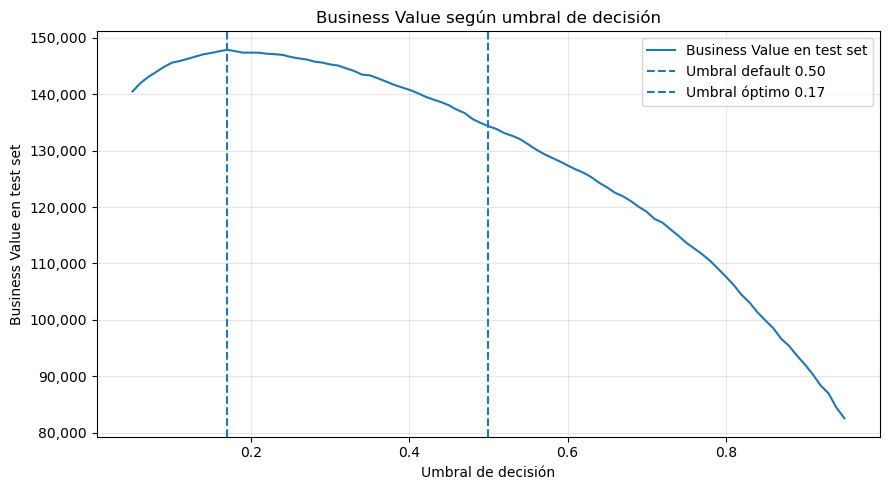

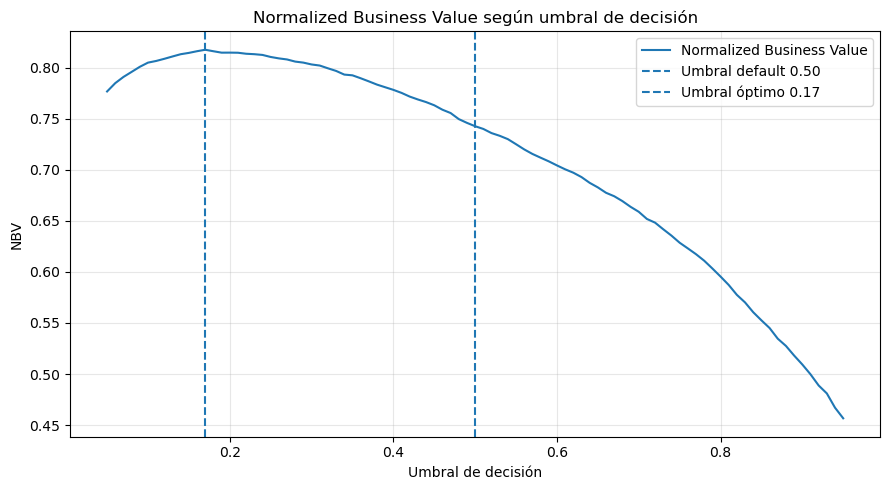

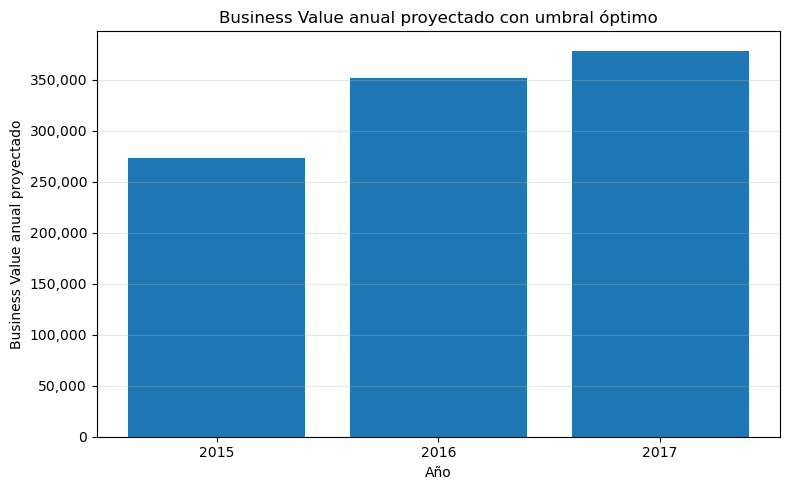

Evaluando modelo: Baseline RF (S3)
Evaluando modelo: Tuned RF (S4)
Evaluando modelo: Tuned XGB (S4)
Evaluando modelo: Hard Voting (S4)
Evaluando modelo: Soft Voting (S4)
Evaluando modelo: Stacking (S4)


,Ranking,Modelo,Threshold,BV,NBV,AUC,TP/P,FP/N,Precision,Recall,F1-score,Accuracy,TP,FP,FN,TN,Acciones preventivas
0,1,Soft Voting (S4),0.26,"147,868.04",0.818,0.935,0.917,0.239,0.693,0.917,0.789,0.819,"8,105","3,588",734,"11,414","11,693"
1,2,Tuned XGB (S4),0.17,"147,860.91",0.818,0.936,0.923,0.253,0.682,0.923,0.785,0.812,"8,155","3,794",684,"11,208","11,949"
2,3,Stacking (S4),0.19,"147,822.84",0.817,0.935,0.909,0.222,0.707,0.909,0.796,0.827,"8,039","3,327",800,"11,675","11,366"
3,4,Baseline RF (S3),0.28,"146,946.83",0.813,0.934,0.906,0.224,0.704,0.906,0.792,0.824,"8,004","3,359",835,"11,643","11,363"
4,5,Tuned RF (S4),0.24,"146,725.72",0.811,0.931,0.915,0.250,0.683,0.915,0.782,0.811,"8,089","3,751",750,"11,251","11,840"
5,6,Hard Voting (S4),nan,"132,042.60",0.730,nan,0.761,0.074,0.858,0.761,0.807,0.865,"6,727","1,115","2,112","13,887","7,842"


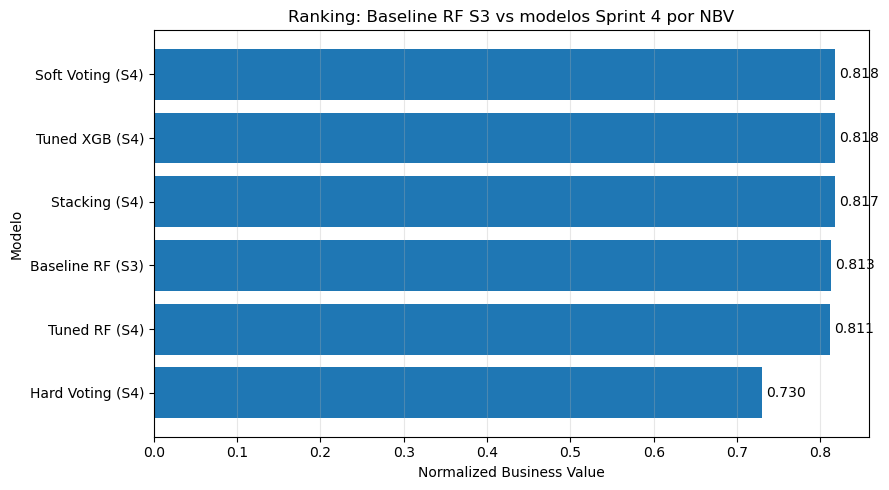

In [10]:
# ========================
# UMBRAL ÓPTIMO POR BUSINESS VALUE
# Y COMPARACIÓN DE MODELOS POR NBV
# ========================

import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

sys.path.append(os.path.abspath(".."))

# ========================
# 1. Verificar / cargar test set
# ========================

if "X_test" not in globals() or "y_test" not in globals():
    df = pd.read_csv("../data/interim/hotel_bookings_fe.csv")

    X = df.drop("is_canceled", axis=1)
    y = df["is_canceled"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    print("Test set cargado desde ../data/interim/hotel_bookings_fe.csv")
else:
    print("Se reutiliza X_test e y_test existentes en el notebook")

# ========================
# 2. Supuestos económicos
# ========================

ADR_PROMEDIO = 101.83
EFECTIVIDAD_OPERATIVA = 0.25
COSTO_ACCION = 5.00

GAIN_TP = ADR_PROMEDIO * EFECTIVIDAD_OPERATIVA

P = np.sum(np.array(y_test) == 1)

# Modelo perfecto: TP = P, FP = 0
BV_MAX = (GAIN_TP * P) - (COSTO_ACCION * P)

print("=== SUPUESTOS ECONÓMICOS ===")
print(f"ADR promedio: {ADR_PROMEDIO:.2f}")
print(f"Efectividad operativa: {EFECTIVIDAD_OPERATIVA:.0%}")
print(f"Gain esperado por TP: {GAIN_TP:.2f}")
print(f"Costo por acción preventiva: {COSTO_ACCION:.2f}")
print(f"Cancelaciones reales en test (P): {P:,}")
print(f"BV máximo posible: {BV_MAX:,.2f}")

# ========================
# 3. Cargar modelo final Tuned XGBoost
# ========================

modelo_final = joblib.load("../models/tuned_xgb.pkl")
nombre_modelo_final = "Tuned XGBoost"

y_proba = modelo_final.predict_proba(X_test)[:, 1]

# ========================
# 4. Evaluar umbrales del modelo final
# ========================

thresholds = np.arange(0.05, 0.96, 0.01)

resultados_umbral = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    bv_test = (tp * GAIN_TP) - ((tp + fp) * COSTO_ACCION)
    nbv_test = bv_test / BV_MAX if BV_MAX != 0 else 0

    resultados_umbral.append({
        "threshold": threshold,
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "Acciones preventivas": int(tp + fp),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "BV test set": bv_test,
        "NBV test set": nbv_test
    })

resultados_umbral = pd.DataFrame(resultados_umbral)

# ========================
# 5. Identificar umbral óptimo por BV
# ========================

idx_best = resultados_umbral["BV test set"].idxmax()
best_threshold_row = resultados_umbral.loc[idx_best]
best_threshold = best_threshold_row["threshold"]

default_row = resultados_umbral.iloc[
    (resultados_umbral["threshold"] - 0.50).abs().argsort()[:1]
]

comparacion_umbral = pd.concat([
    default_row.assign(Escenario="Umbral default 0.50"),
    best_threshold_row.to_frame().T.assign(Escenario="Umbral óptimo por BV")
], ignore_index=True)

comparacion_umbral = comparacion_umbral[
    [
        "Escenario",
        "threshold",
        "TP",
        "FP",
        "FN",
        "TN",
        "Acciones preventivas",
        "Precision",
        "Recall",
        "F1-score",
        "Accuracy",
        "BV test set",
        "NBV test set"
    ]
]

display(
    comparacion_umbral.style.format({
        "threshold": "{:.2f}",
        "TP": "{:,.0f}",
        "FP": "{:,.0f}",
        "FN": "{:,.0f}",
        "TN": "{:,.0f}",
        "Acciones preventivas": "{:,.0f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "Accuracy": "{:.4f}",
        "BV test set": "{:,.2f}",
        "NBV test set": "{:.3f}"
    })
)

# ========================
# 6. Escalar BV del test set a proyección anual
# ========================

proyeccion_anual = pd.DataFrame({
    "Año": [2015, 2016, 2017],
    "Meses disponibles": [6, 12, 8],
    "Reservas observadas": [21996, 56707, 40687],
    "Promedio mensual": [3666.00, 4725.58, 5085.88],
    "Proyección anual": [43992, 56707, 61030]
})

reservas_test = len(y_test)
valor_test_optimo = best_threshold_row["BV test set"]

proyeccion_valor_anual = proyeccion_anual.copy()

proyeccion_valor_anual["Factor escala vs test"] = (
    proyeccion_valor_anual["Proyección anual"] / reservas_test
)

proyeccion_valor_anual["BV anual proyectado"] = (
    valor_test_optimo * proyeccion_valor_anual["Factor escala vs test"]
).round(2)

display(
    proyeccion_valor_anual.style.format({
        "Año": "{:.0f}",
        "Meses disponibles": "{:.0f}",
        "Reservas observadas": "{:,.0f}",
        "Promedio mensual": "{:,.2f}",
        "Proyección anual": "{:,.0f}",
        "Factor escala vs test": "{:.3f}",
        "BV anual proyectado": "{:,.2f}"
    })
)

# ========================
# 7. Resumen ejecutivo
# ========================

print("=== UMBRAL ÓPTIMO DE NEGOCIO ===")
print(f"Modelo final: {nombre_modelo_final}")
print(f"Reservas en test set: {reservas_test:,}")
print(f"Umbral óptimo: {best_threshold:.2f}")
print(f"Business Value en test set: {valor_test_optimo:,.2f}")
print(f"Normalized Business Value: {best_threshold_row['NBV test set']:.3f}")
print(f"Recall: {best_threshold_row['Recall']:.4f}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"F1-score: {best_threshold_row['F1-score']:.4f}")
print(f"Accuracy: {best_threshold_row['Accuracy']:.4f}")

print()
print("=== PROYECCIÓN ANUAL DEL BUSINESS VALUE ===")
for _, row in proyeccion_valor_anual.iterrows():
    print(
        f"{int(row['Año'])}: "
        f"{int(row['Proyección anual']):,} reservas proyectadas → "
        f"{row['BV anual proyectado']:,.2f}"
    )

# ========================
# 8. Gráfico 1: BV por umbral
# ========================

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    resultados_umbral["threshold"],
    resultados_umbral["BV test set"],
    label="Business Value en test set"
)

ax.axvline(
    x=0.50,
    linestyle="--",
    label="Umbral default 0.50"
)

ax.axvline(
    x=best_threshold,
    linestyle="--",
    label=f"Umbral óptimo {best_threshold:.2f}"
)

ax.set_title("Business Value según umbral de decisión")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Business Value en test set")
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

# ========================
# 9. Gráfico 2: NBV por umbral
# ========================

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    resultados_umbral["threshold"],
    resultados_umbral["NBV test set"],
    label="Normalized Business Value"
)

ax.axvline(
    x=0.50,
    linestyle="--",
    label="Umbral default 0.50"
)

ax.axvline(
    x=best_threshold,
    linestyle="--",
    label=f"Umbral óptimo {best_threshold:.2f}"
)

ax.set_title("Normalized Business Value según umbral de decisión")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("NBV")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================
# 10. Gráfico 3: proyección anual del BV
# ========================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    proyeccion_valor_anual["Año"].astype(str),
    proyeccion_valor_anual["BV anual proyectado"]
)

ax.set_title("Business Value anual proyectado con umbral óptimo")
ax.set_xlabel("Año")
ax.set_ylabel("Business Value anual proyectado")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 11. COMPARACIÓN FINAL: BASELINE RF S3 VS MODELOS S4 POR NBV
# ============================================================

modelos_comparacion = {
    "Baseline RF (S3)": "../models/baseline_rf.pkl",
    "Tuned RF (S4)": "../models/tuned_rf.pkl",
    "Tuned XGB (S4)": "../models/tuned_xgb.pkl",
    "Hard Voting (S4)": "../models/ensemble_hv.pkl",
    "Soft Voting (S4)": "../models/ensemble_sv.pkl",
    "Stacking (S4)": "../models/ensemble_stack.pkl"
}

resultados_modelos_bv = []

for nombre_modelo, ruta_modelo in modelos_comparacion.items():

    print(f"Evaluando modelo: {nombre_modelo}")

    modelo = joblib.load(ruta_modelo)

    # Modelos con predict_proba: se optimiza el umbral
    if hasattr(modelo, "predict_proba"):

        try:
            y_proba_modelo = modelo.predict_proba(X_test)[:, 1]

            resultados_tmp = []

            for threshold in thresholds:
                y_pred_modelo = (y_proba_modelo >= threshold).astype(int)

                tn, fp, fn, tp = confusion_matrix(y_test, y_pred_modelo).ravel()

                bv = (tp * GAIN_TP) - ((tp + fp) * COSTO_ACCION)
                nbv = bv / BV_MAX if BV_MAX != 0 else 0

                resultados_tmp.append({
                    "Modelo": nombre_modelo,
                    "Threshold": threshold,
                    "TP": int(tp),
                    "FP": int(fp),
                    "FN": int(fn),
                    "TN": int(tn),
                    "Acciones preventivas": int(tp + fp),
                    "Precision": precision_score(y_test, y_pred_modelo, zero_division=0),
                    "Recall": recall_score(y_test, y_pred_modelo, zero_division=0),
                    "F1-score": f1_score(y_test, y_pred_modelo, zero_division=0),
                    "Accuracy": accuracy_score(y_test, y_pred_modelo),
                    "AUC": roc_auc_score(y_test, y_proba_modelo),
                    "BV": bv,
                    "NBV": nbv,
                    "TP/P": tp / (tp + fn),
                    "FP/N": fp / (fp + tn)
                })

            resultados_tmp = pd.DataFrame(resultados_tmp)

            mejor_fila = resultados_tmp.loc[
                resultados_tmp["BV"].idxmax()
            ]

            resultados_modelos_bv.append(mejor_fila.to_dict())

        except Exception as e:
            print(f"No se pudo calcular predict_proba para {nombre_modelo}: {e}")

    # Modelos sin predict_proba: se evalúa con predict default
    else:
        y_pred_modelo = modelo.predict(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_modelo).ravel()

        bv = (tp * GAIN_TP) - ((tp + fp) * COSTO_ACCION)
        nbv = bv / BV_MAX if BV_MAX != 0 else 0

        resultados_modelos_bv.append({
            "Modelo": nombre_modelo,
            "Threshold": np.nan,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "Acciones preventivas": int(tp + fp),
            "Precision": precision_score(y_test, y_pred_modelo, zero_division=0),
            "Recall": recall_score(y_test, y_pred_modelo, zero_division=0),
            "F1-score": f1_score(y_test, y_pred_modelo, zero_division=0),
            "Accuracy": accuracy_score(y_test, y_pred_modelo),
            "AUC": np.nan,
            "BV": bv,
            "NBV": nbv,
            "TP/P": tp / (tp + fn),
            "FP/N": fp / (fp + tn)
        })

ranking_modelos_bv = pd.DataFrame(resultados_modelos_bv)

ranking_modelos_bv = ranking_modelos_bv.sort_values(
    "NBV",
    ascending=False
).reset_index(drop=True)

ranking_modelos_bv.insert(0, "Ranking", ranking_modelos_bv.index + 1)

ranking_modelos_bv_display = ranking_modelos_bv[
    [
        "Ranking",
        "Modelo",
        "Threshold",
        "BV",
        "NBV",
        "AUC",
        "TP/P",
        "FP/N",
        "Precision",
        "Recall",
        "F1-score",
        "Accuracy",
        "TP",
        "FP",
        "FN",
        "TN",
        "Acciones preventivas"
    ]
]

display(
    ranking_modelos_bv_display.style.format({
        "Ranking": "{:.0f}",
        "Threshold": "{:.2f}",
        "BV": "{:,.2f}",
        "NBV": "{:.3f}",
        "AUC": "{:.3f}",
        "TP/P": "{:.3f}",
        "FP/N": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-score": "{:.3f}",
        "Accuracy": "{:.3f}",
        "TP": "{:,.0f}",
        "FP": "{:,.0f}",
        "FN": "{:,.0f}",
        "TN": "{:,.0f}",
        "Acciones preventivas": "{:,.0f}"
    })
)

# ========================
# 12. Gráfico ranking por NBV
# ========================

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    ranking_modelos_bv["Modelo"],
    ranking_modelos_bv["NBV"]
)

ax.invert_yaxis()
ax.set_title("Ranking: Baseline RF S3 vs modelos Sprint 4 por NBV")
ax.set_xlabel("Normalized Business Value")
ax.set_ylabel("Modelo")

for i, value in enumerate(ranking_modelos_bv["NBV"]):
    ax.text(
        value + 0.005,
        i,
        f"{value:.3f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Aunque Soft Voting obtiene un NBV ligeramente superior, la diferencia frente a Tuned XGBoost es mínima. Por ello, se mantiene Tuned XGBoost como modelo final, ya que ofrece un recall más alto, un valor de negocio prácticamente equivalente y una implementación más simple y eficiente que un ensamble.

### Conclusión del umbral óptimo

El umbral que maximiza el valor esperado de negocio para el modelo **Tuned XGBoost** en el **test set** es **0.17**, con un **Business Value estimado de 147,860.91** sobre **23,841 reservas evaluadas**.

Este resultado confirma que el umbral estándar de **0.50** no es el más adecuado para el objetivo del negocio. Al reducir el umbral a **0.17**, el modelo aumenta el **recall a 0.9226**, lo que permite detectar más reservas que realmente se cancelarán.

Aunque la precision baja a **0.6825** y aumentan las falsas alertas, el resultado sigue siendo favorable porque el modelo captura más cancelaciones reales. Bajo la fórmula corregida, el costo operativo se descuenta sobre todas las reservas intervenidas:

```text
BV = Gain × TP - Cost × (TP + FP)
```

El valor obtenido corresponde solo al test set. Para compararlo con el impacto anual, se escala según la proyección de reservas:

```text
Valor anual proyectado = valor en test set × (reservas anuales proyectadas / reservas en test set)
```

En la comparación por **Normalized Business Value (NBV)**, los mejores resultados fueron **Soft Voting** y **Tuned XGBoost**, ambos con un NBV aproximado de **0.818**, seguidos muy de cerca por **Stacking** con **0.817**. La diferencia entre estos modelos es mínima, pero **Tuned XGBoost** sigue siendo una opción sólida porque mantiene el mayor recall entre los modelos mejor posicionados.

El **Baseline RF (S3)** también muestra un resultado competitivo, con un NBV aproximado de **0.813**, lo que confirma que el baseline ya era fuerte. Sin embargo, los modelos del Sprint 4 logran una ligera mejora al optimizar el umbral de decisión.

Por otro lado, **Hard Voting** obtiene el menor NBV, alrededor de **0.730**, porque no genera probabilidades y no permite ajustar un umbral orientado a negocio. Aunque tiene buena precision y un F1-score aceptable, su recall es menor, por lo que detecta menos cancelaciones reales.

En conclusión, el umbral óptimo debe elegirse como una **decisión de negocio**, manteniendo la lógica del proyecto: priorizar **recall**, validar con **F1-score** y complementar la evaluación con **NBV**.

## 6. Supuestos, fuentes de costos y análisis de sensibilidad

El impacto económico estimado del modelo depende de varios supuestos de negocio. Por ello, esta sección documenta los valores utilizados, su justificación y cómo podrían cambiar los resultados si estos supuestos varían.

El valor económico calculado no debe interpretarse como un ahorro exacto garantizado, sino como una **estimación de valor esperado** basada en supuestos razonables sobre el negocio hotelero.

---

### 6.1 Supuestos principales del análisis

| Supuesto | Valor usado | Fuente o justificación |
|---|---:|---|
| Tasa de cancelación | 37% | Estimada a partir de la media de la variable `is_canceled` |
| ADR promedio | 101.83 | Promedio observado de la variable `ADR` |
| Recall del modelo final | 0.7753 | Resultado del modelo Tuned XGBoost en test set con umbral 0.50 |
| F1-score del modelo final | 0.8125 | Resultado del modelo Tuned XGBoost en test set con umbral 0.50 |
| AUC-ROC del modelo final | 0.9357 | Resultado del modelo Tuned XGBoost en test set |
| Precision del modelo final | 0.8535 | Resultado del modelo Tuned XGBoost en test set con umbral 0.50 |
| Costo operativo por acción preventiva | 5.00 | Supuesto operativo basado en acciones de seguimiento |
| Efectividad operativa base | 25% | Supuesto de negocio sobre recuperación de revenue detectado |
| Umbral óptimo de negocio | 0.17 | Calculado maximizando el Business Value |
| Recall con umbral óptimo | 0.9226 | Resultado del modelo Tuned XGBoost con umbral 0.17 |
| Precision con umbral óptimo | 0.6825 | Resultado del modelo Tuned XGBoost con umbral 0.17 |

---

### 6.2 Fuentes de los costos utilizados

El análisis económico utiliza dos componentes principales:

1. **Gain esperado por detectar correctamente una cancelación real.**
2. **Costo operativo por ejecutar una acción preventiva.**

El gain esperado por cada true positive se aproxima usando el **ADR promedio** y la efectividad operativa asumida:

```text
Gain esperado por TP = ADR promedio × efectividad operativa
```

```text
Gain esperado por TP = 101.83 × 25% = 25.46
```

El costo operativo por acción preventiva se estima en **5.00 unidades monetarias**. Este valor representa un costo promedio asociado a acciones que el equipo operativo o comercial podría realizar sobre reservas marcadas como riesgosas.

| Componente operativo | Costo estimado |
|---|---:|
| Envío de comunicación adicional | 0.50 |
| Revisión administrativa de la alerta | 1.00 |
| Seguimiento comercial o llamada breve | 2.00 |
| Registro y monitoreo de la alerta | 0.50 |
| Posible incentivo menor o gestión adicional | 1.00 |
| **Costo total estimado por acción preventiva** | **5.00** |

A diferencia de la versión inicial del análisis, este costo no se aplica solo a las falsas alertas. Siguiendo la fórmula corregida de Business Value, el costo se descuenta sobre todas las reservas intervenidas por el modelo:

```text
BV = Gain × TP - Cost × (TP + FP)
```

Esto ocurre porque tanto un verdadero positivo como un falso positivo requieren una acción operativa.

---

### 6.3 Justificación del supuesto de efectividad operativa

La efectividad operativa representa el porcentaje del revenue asociado a cancelaciones detectadas que puede recuperarse o compensarse mediante acciones preventivas.

En este análisis se utiliza un escenario base de **25%**.

Esto no significa que el modelo evita el 25% de todas las cancelaciones. Significa que, de las cancelaciones detectadas por el modelo, se asume que una parte puede convertirse en revenue recuperado o pérdida evitada.

| Escenario | Efectividad operativa | Interpretación |
|---|---:|---|
| Conservador | 10% | Pocas alertas logran convertirse en revenue recuperado |
| Base | 25% | Una parte razonable de las alertas genera valor operativo |
| Optimista | 40% | El hotel ejecuta muy bien las acciones preventivas |

El escenario base de **25%** se considera razonable porque no todas las cancelaciones pueden evitarse. Algunas dependen de decisiones definitivas del cliente, cambios de viaje, motivos personales o limitaciones operativas. Sin embargo, una parte sí puede gestionarse mediante confirmaciones anticipadas, políticas de depósito, campañas de retención u overbooking controlado.

---

### 6.4 Rangos de sensibilidad propuestos

Para evaluar la robustez del análisis, se proponen rangos de sensibilidad sobre las variables económicas más importantes.

| Variable | Valor conservador | Valor base | Valor optimista |
|---|---:|---:|---:|
| Efectividad operativa | 10% | 25% | 40% |
| Costo por acción preventiva | 8.00 | 5.00 | 3.00 |
| ADR usado para estimación | 94.58 | 101.83 | 126.00 |

La variable más importante para el impacto económico es la **efectividad operativa**, porque determina qué proporción del revenue detectado puede convertirse realmente en ahorro o ingreso recuperado.

El costo por acción preventiva también es relevante, ya que afecta directamente el valor neto del modelo. Sin embargo, su impacto depende del volumen total de reservas intervenidas, es decir, de la cantidad de verdaderos positivos y falsos positivos generados por el umbral seleccionado.

---

### 6.5 Matriz de sensibilidad sugerida

La siguiente matriz permite interpretar cómo cambiaría el valor del modelo bajo distintos escenarios de efectividad operativa y costo operativo.

| Escenario | Efectividad | Costo por acción preventiva | Interpretación esperada |
|---|---:|---:|---|
| Conservador | 10% | 8.00 | Menor beneficio neto; útil para evaluar el peor caso razonable |
| Base | 25% | 5.00 | Escenario principal del análisis |
| Optimista | 40% | 3.00 | Mayor beneficio neto; supone buena ejecución operativa |

Esta sensibilidad es importante porque el valor del modelo no depende únicamente de su desempeño técnico, sino también de la capacidad del negocio para convertir predicciones en acciones efectivas.

---

### 6.6 Conclusión

Los resultados económicos del modelo deben interpretarse como una **estimación de valor esperado**, no como una garantía de ahorro exacto.

Los principales supuestos utilizados son:

| Supuesto clave | Rol en el análisis |
|---|---|
| ADR promedio | Aproxima el revenue en riesgo por cancelación |
| Efectividad operativa | Estima qué parte de las cancelaciones detectadas puede convertirse en revenue recuperado |
| Costo por acción preventiva | Estima el costo operativo de intervenir reservas marcadas como riesgosas |
| Recall del modelo | Determina cuántas cancelaciones reales logra detectar el modelo |
| Precision del modelo | Influye en la cantidad de falsas alertas y acciones innecesarias |
| Umbral de decisión | Define el balance entre detectar más cancelaciones y generar más intervenciones |

Documentar estos supuestos permite que el análisis sea transparente, ajustable y defendible. Si el negocio obtiene mejores datos de costos reales, tasas de recuperación o efectividad de campañas, los cálculos pueden actualizarse sin cambiar la lógica general del modelo.

En síntesis, el análisis económico complementa la evaluación técnica del modelo. La prioridad sigue siendo detectar cancelaciones reales mediante un alto **recall**, validar el equilibrio con **F1-score** y complementar la decisión con métricas de valor económico como **Business Value** y **NBV**.

,% cancelaciones detectadas recuperadas,Costo por acción preventiva,Cancelaciones detectadas correctamente,Falsas alertas,Acciones preventivas totales,Gain esperado por cancelación detectada,Business Value esperado
0,10%,3.00,"8,155","3,794","11,949",10.18,"47,195.37"
1,10%,5.00,"8,155","3,794","11,949",10.18,"23,297.37"
2,10%,8.00,"8,155","3,794","11,949",10.18,"-12,549.63"
3,25%,3.00,"8,155","3,794","11,949",25.46,"171,758.91"
4,25%,5.00,"8,155","3,794","11,949",25.46,"147,860.91"
5,25%,8.00,"8,155","3,794","11,949",25.46,"112,013.91"
6,40%,3.00,"8,155","3,794","11,949",40.73,"296,322.46"
7,40%,5.00,"8,155","3,794","11,949",40.73,"272,424.46"
8,40%,8.00,"8,155","3,794","11,949",40.73,"236,577.46"


,Costo 3,Costo 5,Costo 8
% cancelaciones detectadas recuperadas,,,
10%,"47,195.37","23,297.37","-12,549.63"
25%,"171,758.91","147,860.91","112,013.91"
40%,"296,322.46","272,424.46","236,577.46"


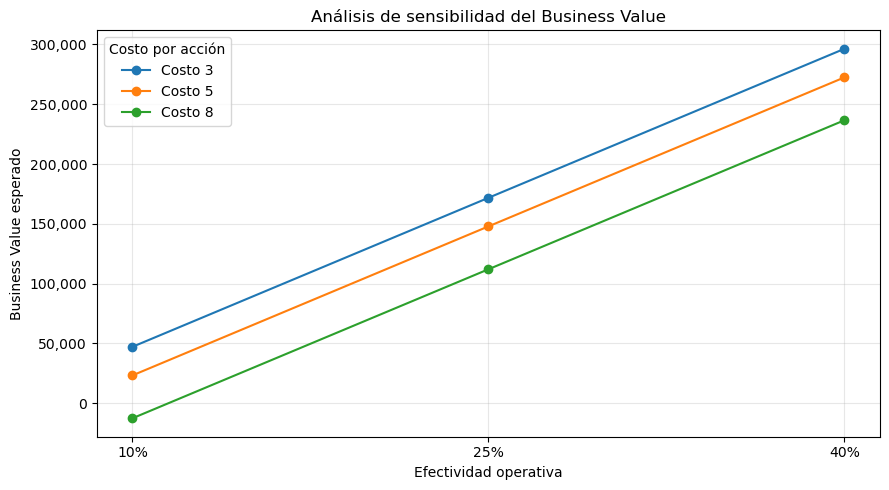

=== ESCENARIO BASE ===
Umbral de negocio usado: 0.17
TP: 8,155
FP: 3,794
FN: 684
TN: 11,208
Acciones preventivas totales: 11,949
Business Value esperado escenario base: 147,860.91


In [11]:
# ========================
# ANÁLISIS DE SENSIBILIDAD CON NOMBRES DE NEGOCIO
# Fórmula: BV = Gain * TP - Cost * (TP + FP)
# ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import confusion_matrix

# ========================
# 1. Parámetros base
# ========================

# Usar el umbral óptimo encontrado en el punto 5
threshold_negocio = best_threshold

# Predicciones con umbral óptimo
y_pred_business = (y_proba >= threshold_negocio).astype(int)

# Matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_business).ravel()

# Convertir a enteros para evitar decimales innecesarios
tn = int(tn)
fp = int(fp)
fn = int(fn)
tp = int(tp)

# Supuestos económicos
ADR_PROMEDIO = 101.83

efectividades = [0.10, 0.25, 0.40]
costos_accion = [3.00, 5.00, 8.00]

# ========================
# 2. Calcular sensibilidad
# ========================

sensibilidad = []

for efectividad in efectividades:
    for costo_accion in costos_accion:
        
        gain_tp = ADR_PROMEDIO * efectividad
        
        # Fórmula corregida:
        # BV = Gain * TP - Cost * (TP + FP)
        business_value = (tp * gain_tp) - ((tp + fp) * costo_accion)
        
        sensibilidad.append({
            "% cancelaciones detectadas recuperadas": f"{efectividad:.0%}",
            "Costo por acción preventiva": costo_accion,
            "Cancelaciones detectadas correctamente": tp,
            "Falsas alertas": fp,
            "Acciones preventivas totales": tp + fp,
            "Gain esperado por cancelación detectada": round(gain_tp, 2),
            "Business Value esperado": round(business_value, 2)
        })

sensibilidad_df = pd.DataFrame(sensibilidad)

# Mostrar tabla principal
display(
    sensibilidad_df.style.format({
        "Costo por acción preventiva": "{:,.2f}",
        "Cancelaciones detectadas correctamente": "{:,.0f}",
        "Falsas alertas": "{:,.0f}",
        "Acciones preventivas totales": "{:,.0f}",
        "Gain esperado por cancelación detectada": "{:,.2f}",
        "Business Value esperado": "{:,.2f}"
    })
)

# ========================
# 3. Crear tabla pivote para lectura rápida
# ========================

sensibilidad_pivot = sensibilidad_df.pivot(
    index="% cancelaciones detectadas recuperadas",
    columns="Costo por acción preventiva",
    values="Business Value esperado"
)

# Quitar decimales innecesarios en encabezados de costo
sensibilidad_pivot.columns = [
    f"Costo {int(col)}" if float(col).is_integer() else f"Costo {col:g}"
    for col in sensibilidad_pivot.columns
]

display(
    sensibilidad_pivot.style.format("{:,.2f}")
)

# ========================
# 4. Gráfico de sensibilidad
# ========================

fig, ax = plt.subplots(figsize=(9, 5))

for costo_col in sensibilidad_pivot.columns:
    ax.plot(
        sensibilidad_pivot.index,
        sensibilidad_pivot[costo_col],
        marker="o",
        label=costo_col
    )

ax.set_title("Análisis de sensibilidad del Business Value")
ax.set_xlabel("Efectividad operativa")
ax.set_ylabel("Business Value esperado")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.legend(title="Costo por acción")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================
# 5. Resumen de escenario base
# ========================

escenario_base = sensibilidad_df[
    (sensibilidad_df["% cancelaciones detectadas recuperadas"] == "25%") &
    (sensibilidad_df["Costo por acción preventiva"] == 5.00)
]

print("=== ESCENARIO BASE ===")
print(f"Umbral de negocio usado: {threshold_negocio:.2f}")
print(f"TP: {tp:,}")
print(f"FP: {fp:,}")
print(f"FN: {fn:,}")
print(f"TN: {tn:,}")
print(f"Acciones preventivas totales: {tp + fp:,}")

if not escenario_base.empty:
    bv_base = escenario_base["Business Value esperado"].iloc[0]
    print(f"Business Value esperado escenario base: {bv_base:,.2f}")

## Conclusión general

El análisis de valor de negocio permitió conectar las métricas del modelo con decisiones económicas y operativas del hotel.

Los criterios de éxito definidos desde el **Sprint 1** se mantienen alineados con la evaluación del **Sprint 4**: se prioriza el **recall** para detectar la mayor cantidad posible de cancelaciones reales, luego el **F1-score** para controlar el balance con falsas alertas, y finalmente el **AUC-ROC** y el **NBV** como métricas complementarias.

La matriz costo-beneficio mostró que no detectar una cancelación real representa una oportunidad perdida de intervención. Por ello, el modelo debe priorizar la detección de cancelaciones, incluso si esto implica aceptar más falsas alertas dentro de un rango operativo razonable.

El análisis económico anual, la gain curve, el lift y la optimización del umbral muestran que el modelo puede generar valor al priorizar reservas de mayor riesgo. En particular, el umbral óptimo de **0.17** para **Tuned XGBoost** confirma que el umbral estándar de **0.50** no necesariamente maximiza el valor de negocio.

Además, la comparación por **Normalized Business Value (NBV)** mostró que los modelos del Sprint 4 logran un desempeño económico competitivo frente al mejor baseline. Aunque **Soft Voting** obtiene un NBV ligeramente superior, **Tuned XGBoost** se mantiene como una alternativa sólida por su mayor recall, su valor económico prácticamente equivalente y su menor complejidad frente a un ensamble.

En contraste, **Hard Voting** presenta un menor NBV porque no permite ajustar un umbral de decisión basado en probabilidades. Aunque tiene buena precision y un F1-score aceptable, su recall es menor, lo que reduce su capacidad de detectar cancelaciones reales.

En conclusión, el modelo tiene potencial para reducir pérdidas por cancelaciones, mejorar la priorización operativa y convertir predicciones en acciones concretas como confirmaciones, campañas de retención, depósitos u overbooking controlado. La decisión final no debe basarse solo en accuracy, sino en una lectura conjunta de **recall**, **F1-score** y **valor económico esperado**.